In [ ]:
!CUDA_VISIBLE_DEVICES=4,5,7,9

In [2]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

In [ ]:


os.environ['CUDA_VISIBLE_DEVICES'] = '4,5,7,9'


img_path = '../data/debug/golf.jpg'
model_type = "vit_b"

if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
elif model_type == "vit_b":
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Load the image as a numpy array (BGR format by default)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)

#visualize the image
plt.imshow(image)
plt.show()

sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image) 

#visualize the masks
plt.imshow(image)
for mask in masks:
    plt.imshow(mask['segmentation'])
    plt.show()


In [ ]:
!nvidia-smi

Processing image: ../data/debug/golf.jpg
Looking for: Golf-Swing
Original image shape: (4109, 6163, 3)
Resized image shape: (256, 256, 3)


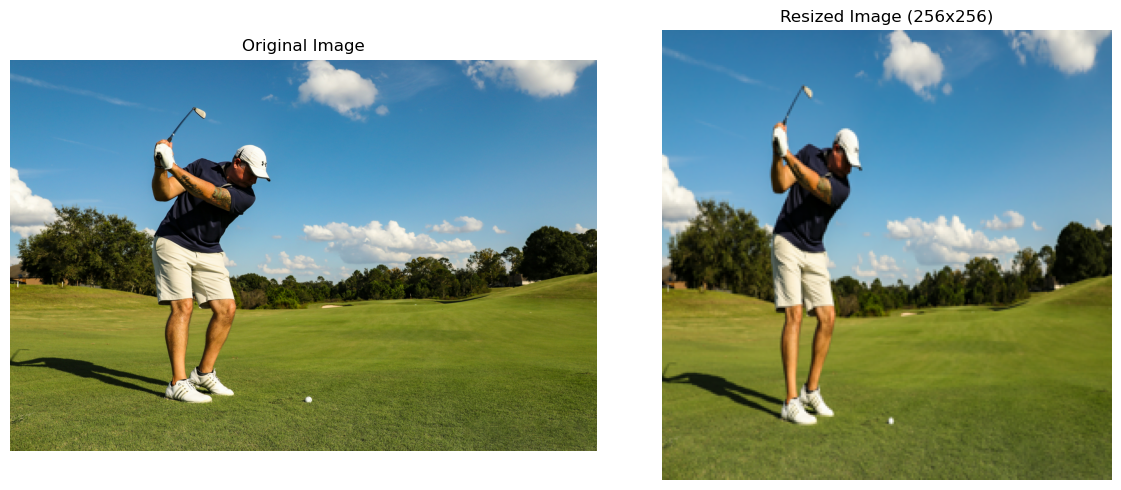

In [3]:
import sys
import os
from PIL import Image
import torch
import torchvision.transforms as transforms

# Add GroundingDINO to path
sys.path.append('/home/sbeeredd/sandbox/GroundingDINO')
from groundingdino.util.inference import load_model, predict, annotate
import groundingdino.datasets.transforms as T
from segment_anything import SamPredictor, sam_model_registry

# Image path and class name for detection
img_path = '../data/debug/golf.jpg'
class_name = "Golf-Swing"  # Class name for GroundingDINO detection

print(f"Processing image: {img_path}")
print(f"Looking for: {class_name}")

# Load and prepare the image
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Original image shape: {image_rgb.shape}")

# Resize image to 256x256 like in UCF dataset
pil_image = Image.fromarray(image_rgb)
resized_image = pil_image.resize((256, 256))
resized_image_np = np.array(resized_image)

print(f"Resized image shape: {resized_image_np.shape}")

# Display original and resized images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(resized_image_np)
axes[1].set_title('Resized Image (256x256)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Step 1: Initialize GroundingDINO Model
print("=== Step 1: GroundingDINO Object Detection ===")

# Load GroundingDINO model
model_grounding = load_model("../../GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py", 
                            "../../GroundingDINO/weights/groundingdino_swint_ogc.pth")

# Create GroundingDINO transform
grounding_transform = T.Compose([
    T.RandomResize([800], max_size=1333),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Transform the PIL image for GroundingDINO
image_transformed, _ = grounding_transform(resized_image, None)
print(f"Transformed image shape for GroundingDINO: {image_transformed.shape}")

# Use GroundingDINO to detect objects
boxes, logits, phrases = predict(
    model=model_grounding,
    image=image_transformed,
    caption=class_name,
    box_threshold=0.35,
    text_threshold=0.25
)

print(f"GroundingDINO Results:")
print(f"  - Found {len(boxes)} boxes")
print(f"  - Detected phrases: {phrases}")
print(f"  - Detection confidence (logits): {logits}")

# Visualize GroundingDINO detection results
if len(boxes) > 0:
    annotated_image = annotate(image_source=resized_image, boxes=boxes, logits=logits, phrases=phrases)
    
    # Display side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].imshow(resized_image_np)
    axes[0].set_title('Original Resized Image')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'GroundingDINO Detection: {class_name}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"No objects detected for '{class_name}'")
    plt.imshow(resized_image_np)
    plt.title(f'No Detection Found for: {class_name}')
    plt.axis('off')
    plt.show()


=== Step 1: GroundingDINO Object Detection ===


final text_encoder_type: bert-base-uncased


Transformed image shape for GroundingDINO: torch.Size([3, 800, 800])


NameError: name '_C' is not defined

In [ ]:
# Step 2: Initialize SAM Model and Segment
print("=== Step 2: SAM Segmentation ===")

# SAM model configuration
model_type = "vit_b"
if model_type == "vit_h":
    checkpoint_path = "../checkpoints/SAM/sam_vit_h_4b8939.pth"
elif model_type == "vit_l":
    checkpoint_path = "../checkpoints/SAM/sam_vit_l_0b3195.pth"
else:  # vit_b
    checkpoint_path = "../checkpoints/SAM/sam_vit_b_01ec64.pth"

# Initialize SAM
sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
sam.cuda()
predictor = SamPredictor(sam)

# Set image for SAM
predictor.set_image(resized_image_np)

# Use SAM to segment using GroundingDINO bounding boxes
if len(boxes) > 0:
    # Use the first detected box
    input_box = boxes[0]
    print(f"Using bounding box: {input_box}")
    
    masks, scores, logits_sam = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box,
        multimask_output=True,
    )
    
    print(f"SAM Results:")
    print(f"  - Generated {len(masks)} masks")
    print(f"  - Mask scores: {scores}")
    print(f"  - Best mask index: {np.argmax(scores)}")
    
    # Select the best mask
    best_mask_idx = np.argmax(scores)
    best_mask = masks[best_mask_idx]
    
    print(f"  - Best mask shape: {best_mask.shape}")
    print(f"  - Mask coverage: {np.sum(best_mask) / (best_mask.shape[0] * best_mask.shape[1]):.2%}")
    
else:
    # No boxes found, generate mask without prompt
    print("No bounding boxes available, generating mask without prompt...")
    masks, scores, logits_sam = predictor.predict(
        point_coords=None,
        point_labels=None,
        multimask_output=True,
    )
    
    if len(masks) > 0:
        best_mask_idx = np.argmax(scores)
        best_mask = masks[best_mask_idx]
        print(f"Generated {len(masks)} masks without prompt")
    else:
        print("No masks generated")
        best_mask = np.ones_like(resized_image_np[:,:,0])  # Use full image as fallback


In [ ]:
# Visualize SAM segmentation results
print("=== Step 2.1: SAM Mask Visualization ===")

if len(boxes) > 0:
    # Show all generated masks
    fig, axes = plt.subplots(2, len(masks), figsize=(5*len(masks), 10))
    
    for i, (mask, score) in enumerate(zip(masks, scores)):
        # Top row: mask overlay on original image
        axes[0, i].imshow(resized_image_np)
        axes[0, i].imshow(mask, alpha=0.5, cmap='jet')
        axes[0, i].set_title(f'Mask {i} (Score: {score:.3f})')
        axes[0, i].axis('off')
        
        # Bottom row: mask only
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Mask {i} Binary')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Highlight the best mask
    print(f"Best mask (index {best_mask_idx}) with score {scores[best_mask_idx]:.3f}")
    
else:
    # Just show the mask without multiple options
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(resized_image_np)
    plt.imshow(best_mask, alpha=0.5, cmap='jet')
    plt.title('Mask Overlay')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(best_mask, cmap='gray')
    plt.title('Binary Mask')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Step 3: Apply mask and zero out background (like in UCF dataset)
print("=== Step 3: Background Masking (UCF Dataset Style) ===")

# Create masked image where background is zeroed out
masked_image_np = resized_image_np.copy().astype(np.float32)

# Apply mask to each channel - zero out background
for c in range(3):
    masked_image_np[:, :, c] = masked_image_np[:, :, c] * best_mask

# Convert back to uint8
masked_image_np = masked_image_np.astype(np.uint8)

print(f"Original image shape: {resized_image_np.shape}")
print(f"Mask shape: {best_mask.shape}")
print(f"Masked image shape: {masked_image_np.shape}")
print(f"Pixels masked out: {np.sum(~best_mask)} / {best_mask.size} ({100 * np.sum(~best_mask) / best_mask.size:.1f}%)")

# Visualize the complete pipeline
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: Pipeline steps
axes[0, 0].imshow(resized_image_np)
axes[0, 0].set_title('Step 1: Original Image')
axes[0, 0].axis('off')

if len(boxes) > 0:
    axes[0, 1].imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Step 2: GroundingDINO Detection')
else:
    axes[0, 1].imshow(resized_image_np)
    axes[0, 1].set_title('Step 2: No Detection')
axes[0, 1].axis('off')

axes[0, 2].imshow(best_mask, cmap='gray')
axes[0, 2].set_title('Step 3: SAM Segmentation Mask')
axes[0, 2].axis('off')

# Bottom row: Final results
axes[1, 0].imshow(resized_image_np)
axes[1, 0].imshow(best_mask, alpha=0.3, cmap='jet')
axes[1, 0].set_title('Mask Overlay on Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(masked_image_np)
axes[1, 1].set_title('Final: Background Zeroed')
axes[1, 1].axis('off')

# Show difference
diff_image = resized_image_np.astype(np.int16) - masked_image_np.astype(np.int16)
diff_image = np.abs(diff_image).astype(np.uint8)
axes[1, 2].imshow(diff_image)
axes[1, 2].set_title('Difference (Removed Background)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Save the results
print(f"=== Step 4: Save Results ===")
output_dir = "debug_pipeline_notebook"
os.makedirs(output_dir, exist_ok=True)

cv2.imwrite(f"{output_dir}/step1_original.jpg", cv2.cvtColor(resized_image_np, cv2.COLOR_RGB2BGR))
if len(boxes) > 0:
    cv2.imwrite(f"{output_dir}/step2_grounding.jpg", annotated_image)
cv2.imwrite(f"{output_dir}/step3_sam_mask.jpg", (best_mask * 255).astype(np.uint8))
cv2.imwrite(f"{output_dir}/step4_masked_bg_zero.jpg", cv2.cvtColor(masked_image_np, cv2.COLOR_RGB2BGR))

print(f"Results saved to {output_dir}/ directory")
print(f"Pipeline complete! Final masked image ready for model training.")


In [ ]:
# Step 4: Apply PyTorch transforms (like in UCF dataset)
print("=== Step 5: PyTorch Transform Pipeline ===")

# Define transforms similar to UCF dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Convert masked image to PIL and apply transforms
masked_image_pil = Image.fromarray(masked_image_np)
transformed_tensor = transform(masked_image_pil)

print(f"Original image shape: {resized_image_np.shape}")
print(f"Masked image shape: {masked_image_np.shape}")
print(f"Final tensor shape: {transformed_tensor.shape}")
print(f"Tensor dtype: {transformed_tensor.dtype}")
print(f"Tensor range: [{transformed_tensor.min():.3f}, {transformed_tensor.max():.3f}]")

# Visualize the tensor (denormalized for display)
def denormalize_tensor(tensor):
    """Denormalize tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    denorm_tensor = tensor * std + mean
    return torch.clamp(denorm_tensor, 0, 1)

denormalized_tensor = denormalize_tensor(transformed_tensor)
final_image_np = (denormalized_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

# Show the complete transformation pipeline
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(resized_image_np)
axes[0].set_title('1. Original Image')
axes[0].axis('off')

axes[1].imshow(masked_image_np)
axes[1].set_title('2. Background Masked')
axes[1].axis('off')

axes[2].imshow(final_image_np)
axes[2].set_title('3. After PyTorch Transform\n(Denormalized for display)')
axes[2].axis('off')

# Show tensor statistics
axes[3].text(0.1, 0.8, f'Tensor Shape: {transformed_tensor.shape}', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.7, f'Data Type: {transformed_tensor.dtype}', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.6, f'Range: [{transformed_tensor.min():.3f}, {transformed_tensor.max():.3f}]', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.5, f'Mean per channel:', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.4, f'  R: {transformed_tensor[0].mean():.3f}', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.3, f'  G: {transformed_tensor[1].mean():.3f}', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.2, f'  B: {transformed_tensor[2].mean():.3f}', fontsize=12, transform=axes[3].transAxes)
axes[3].text(0.1, 0.1, f'Ready for model input!', fontsize=14, fontweight='bold', color='green', transform=axes[3].transAxes)
axes[3].set_xlim(0, 1)
axes[3].set_ylim(0, 1)
axes[3].axis('off')
axes[3].set_title('4. Tensor Statistics')

plt.tight_layout()
plt.show()

print("\\n=== Pipeline Summary ===")
print("✅ 1. Loaded and resized image to 256x256")
print("✅ 2. Used GroundingDINO to detect objects")
print("✅ 3. Used SAM to generate precise segmentation mask")
print("✅ 4. Applied mask to zero out background")
print("✅ 5. Applied PyTorch transforms (normalize)")
print("\\n🎯 Final tensor is ready for model training!")
print(f"   Shape: {transformed_tensor.shape}")
print(f"   Type: {transformed_tensor.dtype}")
print(f"   Device: {transformed_tensor.device}")

# Save the final tensor
torch.save(transformed_tensor, f"{output_dir}/final_tensor.pt")
cv2.imwrite(f"{output_dir}/step5_final_tensor.jpg", cv2.cvtColor(final_image_np, cv2.COLOR_RGB2BGR))
print(f"\\n💾 Final tensor saved to {output_dir}/final_tensor.pt")
